<a href="https://colab.research.google.com/github/Kaushika-M/Customer_Segmentation-Using-Machine-Learning/blob/main/Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_excel("Dataset for Data Analytics.xlsx")

In [3]:
print(df.head(5))

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [4]:
print(df.shape)

(1200, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [6]:
print(df.describe())

                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


In [7]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [8]:
df['CouponCode']=df['CouponCode'].fillna("No coupon")

In [9]:
print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [10]:
print(df.duplicated().sum())

0


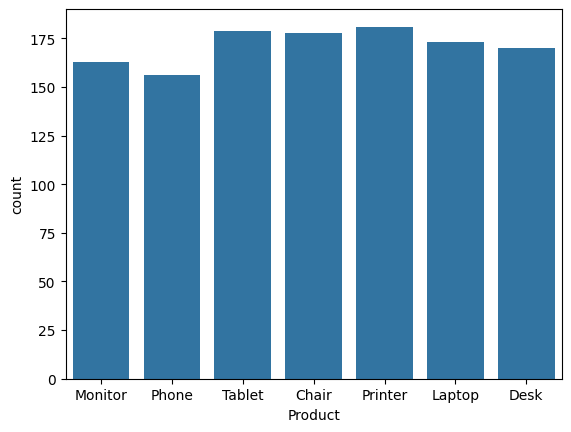

In [11]:
sns.countplot(x='Product',data=df)
plt.show()

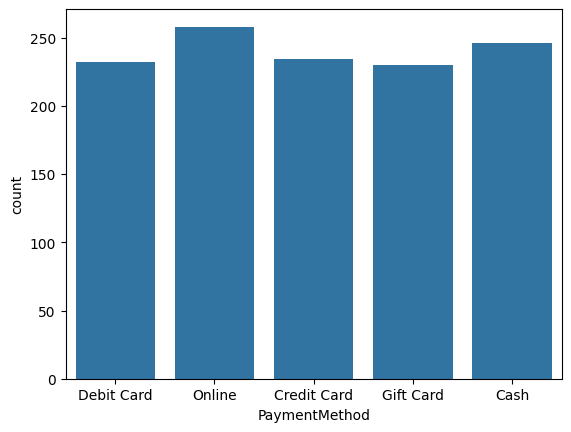

In [12]:
sns.countplot(x='PaymentMethod',data=df)
plt.show()

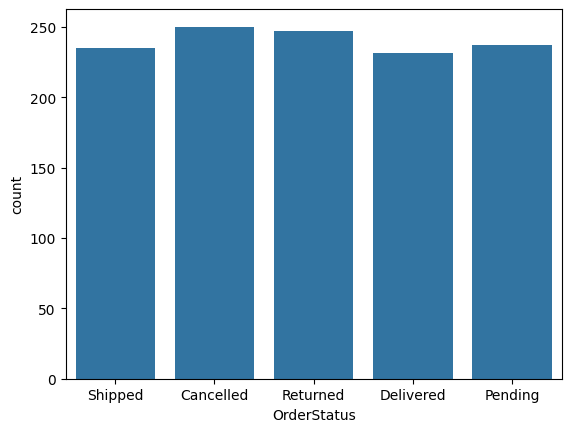

In [13]:
sns.countplot(x='OrderStatus',data=df)
plt.show()

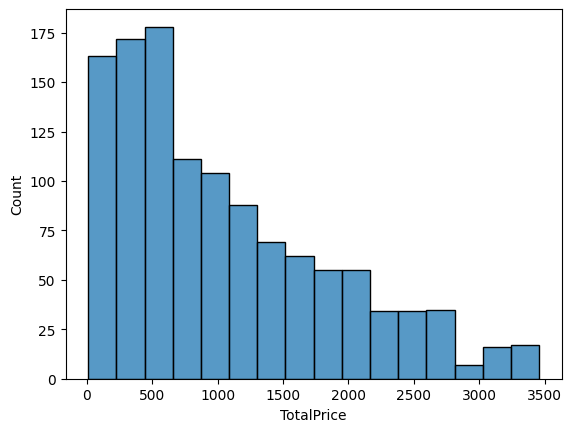

In [14]:
sns.histplot(x='TotalPrice',data=df)
plt.show()

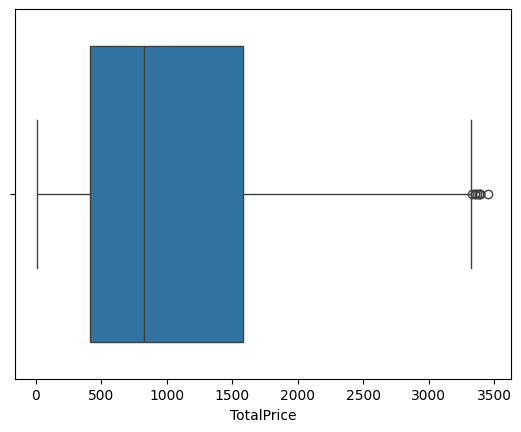

In [15]:
sns.boxplot(x='TotalPrice',data=df)
plt.show()

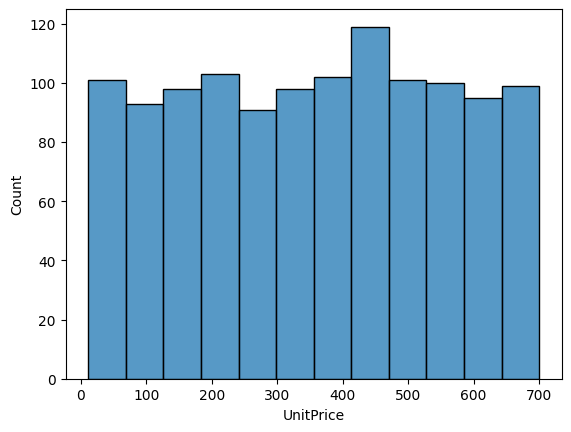

In [16]:
sns.histplot(x='UnitPrice',data=df)
plt.show()

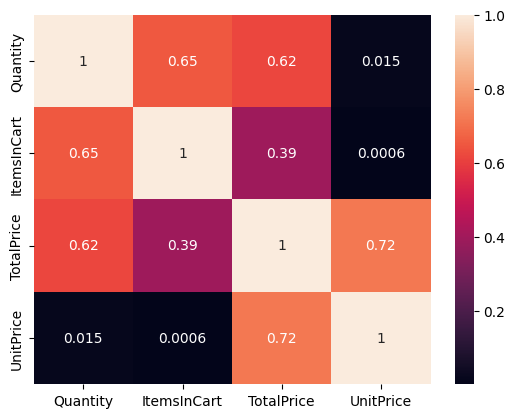

In [17]:
num_col=['Quantity','ItemsInCart','TotalPrice','UnitPrice']
sns.heatmap(df[num_col].corr(),annot=True)
plt.show()

In [18]:
df = df.drop(columns=['Date','OrderID', 'CustomerID', 'TrackingNumber', 'ShippingAddress'], errors='ignore')

In [19]:
df = pd.get_dummies(df,
    columns=['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource'],
    drop_first=True
)

In [20]:
print(df.head())

   Quantity  UnitPrice  ItemsInCart  TotalPrice  Product_Desk  Product_Laptop  \
0         5     570.62            7     2853.10         False           False   
1         2     151.35            3      302.70         False           False   
2         5     550.68            8     2753.40         False           False   
3         1     273.19            5      273.19         False           False   
4         4     626.01            8     2504.04         False           False   

   Product_Monitor  Product_Phone  Product_Printer  Product_Tablet  ...  \
0             True          False            False           False  ...   
1            False           True            False           False  ...   
2            False          False            False            True  ...   
3            False          False            False           False  ...   
4            False          False             True           False  ...   

   OrderStatus_Pending  OrderStatus_Returned  OrderStatus_Ship

In [21]:
print(df.dtypes)

Quantity                       int64
UnitPrice                    float64
ItemsInCart                    int64
TotalPrice                   float64
Product_Desk                    bool
Product_Laptop                  bool
Product_Monitor                 bool
Product_Phone                   bool
Product_Printer                 bool
Product_Tablet                  bool
PaymentMethod_Credit Card       bool
PaymentMethod_Debit Card        bool
PaymentMethod_Gift Card         bool
PaymentMethod_Online            bool
OrderStatus_Delivered           bool
OrderStatus_Pending             bool
OrderStatus_Returned            bool
OrderStatus_Shipped             bool
CouponCode_No coupon            bool
CouponCode_SAVE10               bool
CouponCode_WINTER15             bool
ReferralSource_Facebook         bool
ReferralSource_Google           bool
ReferralSource_Instagram        bool
ReferralSource_Referral         bool
dtype: object


In [22]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)
print(scaled_data[:5])

[[ 1.45999271  1.0868225   0.66417297  2.19536185 -0.40626167 -0.4104288
   2.52229324 -0.38655567 -0.42145596 -0.4187103  -0.49217479  2.04264872
  -0.48694291 -0.52334057 -0.48825208 -0.49609064 -0.50909874  2.02642122
  -0.58889842  1.78768123 -0.56708545 -0.4843221  -0.50130175  1.9060967
  -0.47643873]
 [-0.67224817 -1.04042608 -1.08941903 -0.9167232  -0.40626167 -0.4104288
  -0.39646461  2.5869495  -0.42145596 -0.4187103  -0.49217479 -0.48956044
  -0.48694291  1.91080161 -0.48825208 -0.49609064 -0.50909874  2.02642122
  -0.58889842  1.78768123 -0.56708545 -0.4843221  -0.50130175 -0.52463235
   2.09890576]
 [ 1.45999271  0.985653    1.10257097  2.07370451 -0.40626167 -0.4104288
  -0.39646461 -0.38655567 -0.42145596  2.38828612  2.0317985  -0.48956044
  -0.48694291 -0.52334057 -0.48825208 -0.49609064 -0.50909874 -0.49348082
  -0.58889842 -0.55938384 -0.56708545 -0.4843221  -0.50130175 -0.52463235
  -0.47643873]
 [-1.38299512 -0.42224695 -0.21262303 -0.9527323  -0.40626167 -0.410428

In [23]:
print(scaled_data.shape)

(1200, 25)


In [24]:
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_data)

In [25]:
print(pca_data.shape)

(1200, 3)


In [26]:
print(pca.explained_variance_ratio_)

[0.09155784 0.05931548 0.05852047]


In [27]:
wcss=[]
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(pca_data)
  wcss.append(kmeans.inertia_)

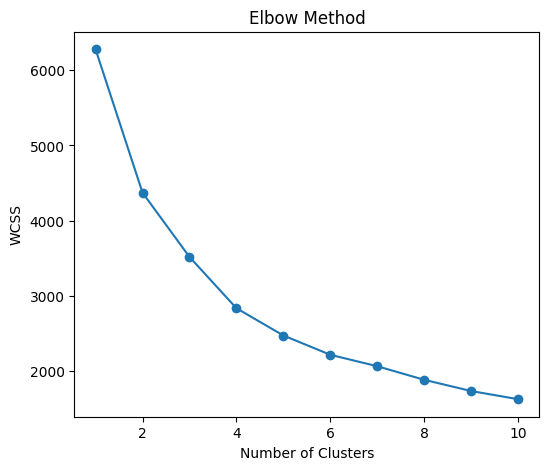

In [28]:
plt.figure(figsize=(6,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [29]:
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    print(f"K = {i}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.278
K = 3, Silhouette Score = 0.256
K = 4, Silhouette Score = 0.272
K = 5, Silhouette Score = 0.257
K = 6, Silhouette Score = 0.249
K = 7, Silhouette Score = 0.234
K = 8, Silhouette Score = 0.231
K = 9, Silhouette Score = 0.236
K = 10, Silhouette Score = 0.234


In [31]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(pca_data)


In [32]:
df['Cluster'] = clusters
print(df['Cluster'].value_counts())

Cluster
0    681
1    519
Name: count, dtype: int64


In [33]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         Quantity   UnitPrice  ItemsInCart   TotalPrice  Product_Desk  \
Cluster                                                                 
0        2.071953  290.866946     4.317181   519.497239      0.133627   
1        4.092486  442.417938     7.017341  1755.268478      0.152216   

         Product_Laptop  Product_Monitor  Product_Phone  Product_Printer  \
Cluster                                                                    
0              0.133627         0.129222       0.161527         0.151248   
1              0.157996         0.144509       0.088632         0.150289   

         Product_Tablet  ...  OrderStatus_Pending  OrderStatus_Returned  \
Cluster                  ...                                              
0              0.162996  ...             0.174743              0.223201   
1              0.131021  ...             0.227360              0.183044   

         OrderStatus_Shipped  CouponCode_No coupon  CouponCode_SAVE10  \
Cluster                     

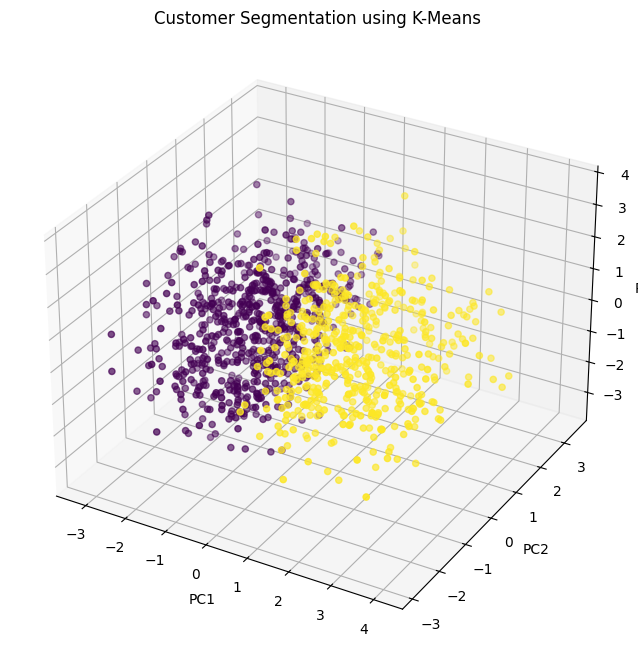

In [34]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_data[:,0],
    pca_data[:,1],
    pca_data[:,2],
    c=clusters
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Customer Segmentation using K-Means")

plt.show()